<a href="https://colab.research.google.com/github/mariajosemuskusl/Integracion-de-Datos-y-Prospectiva/blob/main/Parcial_2_Gesti%C3%B3n_Prospectiva_de_Riesgos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Parcial 2**

**Gestión Prospectiva de Fallas Tecnológicas**  

---
María José Muskus Londoño

**Objetivo**

Una entidad del sector FINTECH esta interesada en implementar un sistema para la gestión prospectiva de riesgos basada en potenciales de captura de Gases de Efecto Invernadero (GEI).

**Metodología**

Para la gestión prospectiva de riesgos se utilizará como base el modelo K-Means sobre la distribución agregada de las pérdidas LDA (Loss Distribution).

**Variables**

- **Fecha:** día en que ocurrió la falla tecnológica.
- **Transacciones_Diarias:** volumen total de transacciones procesadas ese día.
- **Valor_Transado_MM:** valor total transado en millones de USD.
- **Frecuencia:** número de transacciones fallidas en el evento.
- **Severidad:** pérdida económica asociada a la falla (en MM USD).
- **Descripcion_Evento:** descripción del tipo de falla ocurrida.


**0. Cargar librerías de trabajo**

In [77]:
# Cargamos las librerías de trabajo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from scipy.stats import skew

# Conexión con Drive
from google.colab import drive
drive.mount('/content/drive')

# Configuración general de las gráficas
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1. Cargar la base de datos**

In [78]:
# Cargamos el archivo de Excel

nxl = '/content/drive/MyDrive/University/Integración de Datos y Prospectiva/Retos/Reto 4/5. Riesgo Operacional FallasTecnológicas.xlsx'

XDB = pd.read_excel(nxl, sheet_name='Fallas Tecnológicas', header=1)
Xgestion = pd.read_excel(nxl, sheet_name='Gestión', header=1)

XDB.columns = [
    'Fecha',
    'Transacciones_Diarias',
    'Valor_Transado_MM',
    'Frecuencia',
    'Severidad',
    'Descripcion_Evento'
]

Xgestion.columns = ['Nivel', 'Nivel_Gestion', 'Actividades_Gestion', 'Costo_KUSD', 'Desviacion']

XDB.head()

,Fecha,Transacciones_Diarias,Valor_Transado_MM,Frecuencia,Severidad,Descripcion_Evento
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."


In [79]:
# Revisamos el tamaño y la estructura de la base

print('Número de registros:', len(XDB))
print('Columnas:', XDB.columns.tolist())

XDB.describe()

Número de registros: 701
Columnas: ['Fecha', 'Transacciones_Diarias', 'Valor_Transado_MM', 'Frecuencia', 'Severidad', 'Descripcion_Evento']


,Fecha,Transacciones_Diarias,Valor_Transado_MM,Frecuencia,Severidad
count,701,701.000000,701.000000,701.000000,701.000000
mean,2010-06-25 06:30:17.974322176,99.158345,24.248679,4.753210,1.929555
min,2009-01-01 00:00:00,35.000000,-9.957400,1.000000,0.084200
25%,2009-06-25 00:00:00,85.000000,16.851100,2.000000,0.631300
50%,2011-01-01 00:00:00,100.000000,24.162000,4.000000,1.224000
75%,2011-06-25 00:00:00,115.000000,31.537300,7.000000,2.343900
max,2011-12-17 00:00:00,170.000000,59.566900,16.000000,17.312900
std,NaN,22.081130,11.598671,2.984796,2.130130


**2. Construcción de la distribución agregada de pérdidas - LDA**

In [80]:
# Se crean las variables principales del modelo

Xf = np.array(XDB['Frecuencia'])
Xs = np.abs(np.array(XDB['Severidad']))

# Distribución agregada de pérdidas
LDA = Xf * Xs

# Se construye una base de trabajo
DF = pd.DataFrame({
    'Fecha': XDB['Fecha'],
    'Frecuencia': Xf,
    'Severidad': Xs,
    'LDA': LDA,
    'Descripcion_Evento': XDB['Descripcion_Evento']
})

DF.head()

,Fecha,Frecuencia,Severidad,LDA,Descripcion_Evento
0,2009-01-01,1,0.5374,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,4,1.1978,4.7912,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,5,0.4269,2.1345,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,6,1.0814,6.4884,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,7,1.2105,8.4735,"Errores en la interfaz de usuario, fallas en f..."


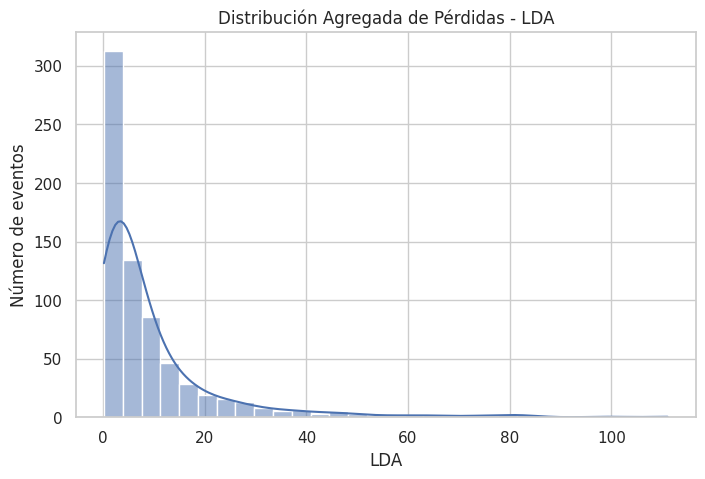

In [81]:
# Gráfica inicial de la distribución de pérdidas

plt.figure(figsize=(8,5))
sns.histplot(DF['LDA'], bins=30, kde=True)
plt.title('Distribución Agregada de Pérdidas - LDA')
plt.xlabel('LDA')
plt.ylabel('Número de eventos')
plt.show()

**3. Clusterización K-Means para los niveles de riesgo**

In [82]:
# Clusterización de la LDA en cinco niveles de riesgo

np.random.seed(42)

X_lda = DF[['LDA']].values

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
DF['Cluster_LDA'] = kmeans.fit_predict(X_lda)

# Ordenamos los clusters de menor a mayor pérdida
centroides = pd.DataFrame({
    'Cluster_LDA': range(5),
    'Centroide': kmeans.cluster_centers_.flatten()
}).sort_values('Centroide')

centroides['Nivel_Riesgo'] = range(1,6)
centroides['Categoria_Riesgo'] = ['AA', 'A', 'BB', 'B', 'C']

DF = DF.merge(centroides[['Cluster_LDA','Nivel_Riesgo','Categoria_Riesgo']], on='Cluster_LDA', how='left')

DF[['Fecha','Frecuencia','Severidad','LDA','Nivel_Riesgo','Categoria_Riesgo']].head()

,Fecha,Frecuencia,Severidad,LDA,Nivel_Riesgo,Categoria_Riesgo
0,2009-01-01,1,0.5374,0.5374,1,AA
1,2009-01-02,4,1.1978,4.7912,1,AA
2,2009-01-03,5,0.4269,2.1345,1,AA
3,2009-01-04,6,1.0814,6.4884,2,A
4,2009-01-05,7,1.2105,8.4735,2,A


In [83]:
# Tabla resumen de los niveles de riesgo

resumen_riesgo = DF.groupby(['Nivel_Riesgo','Categoria_Riesgo']).agg(
    Eventos=('LDA','count'),
    LDA_Min=('LDA','min'),
    LDA_Max=('LDA','max'),
    LDA_Promedio=('LDA','mean'),
    LDA_Total=('LDA','sum')
).reset_index()

resumen_riesgo

,Nivel_Riesgo,Categoria_Riesgo,Eventos,LDA_Min,LDA_Max,LDA_Promedio,LDA_Total
0,1,AA,403,0.1423,5.9550,2.508127,1010.7751
1,2,A,179,6.0432,15.0246,9.514277,1703.0556
2,3,BB,74,15.5727,30.5715,21.285076,1575.0956
3,4,B,31,31.6170,55.6884,40.468916,1254.5364
4,5,C,14,60.0561,111.0830,77.269093,1081.7673


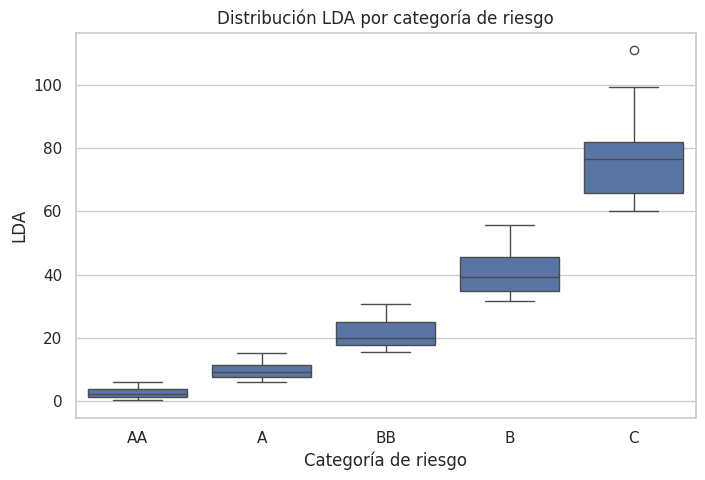

In [84]:
# Visualización de los niveles de riesgo

plt.figure(figsize=(8,5))
sns.boxplot(data=DF, x='Categoria_Riesgo', y='LDA', order=['AA','A','BB','B','C'])
plt.title('Distribución LDA por categoría de riesgo')
plt.xlabel('Categoría de riesgo')
plt.ylabel('LDA')
plt.show()

**4. Parámetros de riesgo de la LDA**

De acuerdo con la lógica del modelo LDA, se calculan los principales parámetros de riesgo:

- **Pérdida esperada:** promedio de la LDA.
- **OpVaR:** percentil 99,9% de la LDA.
- **Pérdidas no esperadas:** eventos entre la pérdida esperada y el OpVaR.
- **Stress losses:** eventos por encima del OpVaR.
- **Asimetría:** forma de la distribución de pérdidas.

In [85]:
# Métricas de la distribución agregada de pérdidas

perdida_esperada = np.mean(DF['LDA'])
opvar = np.percentile(DF['LDA'], 99.9)
asimetria = skew(DF['LDA'])

NPE = np.sum(DF['LDA'] <= perdida_esperada)
NPNE = np.sum((DF['LDA'] > perdida_esperada) & (DF['LDA'] <= opvar))
NPC = np.sum(DF['LDA'] > opvar)

total_eventos = len(DF)

print('Pérdida esperada:', round(perdida_esperada, 4))
print('OpVaR 99.9%:', round(opvar, 4))
print('Número de pérdidas esperadas:', NPE)
print('Número de pérdidas no esperadas:', NPNE)
print('Número de pérdidas catastróficas:', NPC)
print('Total eventos:', total_eventos)
print('Asimetría:', round(asimetria, 4))

Pérdida esperada: 9.4511
OpVaR 99.9%: 102.9021
Número de pérdidas esperadas: 502
Número de pérdidas no esperadas: 198
Número de pérdidas catastróficas: 1
Total eventos: 701
Asimetría: 3.3484


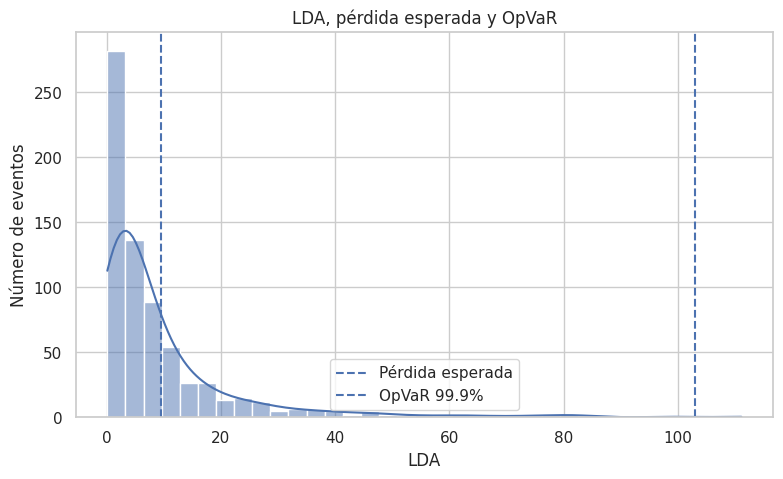

In [86]:
# Gráfica de la LDA con la pérdida esperada y el OpVaR

plt.figure(figsize=(9,5))
sns.histplot(DF['LDA'], bins=35, kde=True)
plt.axvline(perdida_esperada, linestyle='--', label='Pérdida esperada')
plt.axvline(opvar, linestyle='--', label='OpVaR 99.9%')
plt.title('LDA, pérdida esperada y OpVaR')
plt.xlabel('LDA')
plt.ylabel('Número de eventos')
plt.legend()
plt.show()

**5. Mapa de gestión prospectiva**

In [87]:
# Matriz de gestión prospectiva, siguiendo la lógica del Excel del profesor

mapa_gestion = pd.DataFrame({
    1: [1,2,3,4,5],
    2: [1,4,6,8,5],
    3: [1,6,9,12,5],
    4: [1,8,12,16,5],
    5: [1,10,15,20,5]
}, index=[1,2,3,4,5])

mapa_gestion.index.name = 'Nivel_Riesgo'
mapa_gestion.columns.name = 'Nivel_Gestion'

mapa_gestion

Nivel_Gestion,1,2,3,4,5
Nivel_Riesgo,,,,,
1,1,1,1,1,1
2,2,4,6,8,10
3,3,6,9,12,15
4,4,8,12,16,20
5,5,5,5,5,5


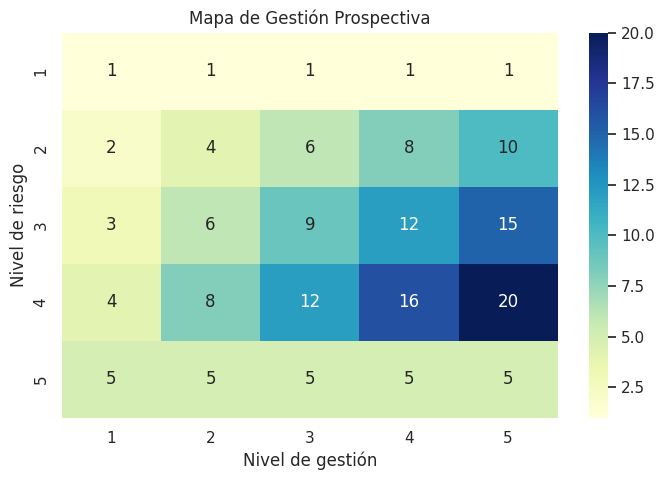

In [88]:
# Visualización del mapa de gestión

plt.figure(figsize=(8,5))
sns.heatmap(mapa_gestion, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Mapa de Gestión Prospectiva')
plt.xlabel('Nivel de gestión')
plt.ylabel('Nivel de riesgo')
plt.show()

**6. Costos de gestión**

In [89]:
# 6. Tabla de costos de gestión disponible en el archivo

costos_gestion = Xgestion[['Nivel','Nivel_Gestion','Costo_KUSD','Desviacion']].copy()
costos_gestion

,Nivel,Nivel_Gestion,Costo_KUSD,Desviacion
0,1,Bajo,0.012171,0.005710
1,2,Medio,0.037437,0.027454
2,3,Moderado,0.173067,0.085586
3,4,Alto,0.407991,0.038555
4,5,Crítico,0.628350,0.076041


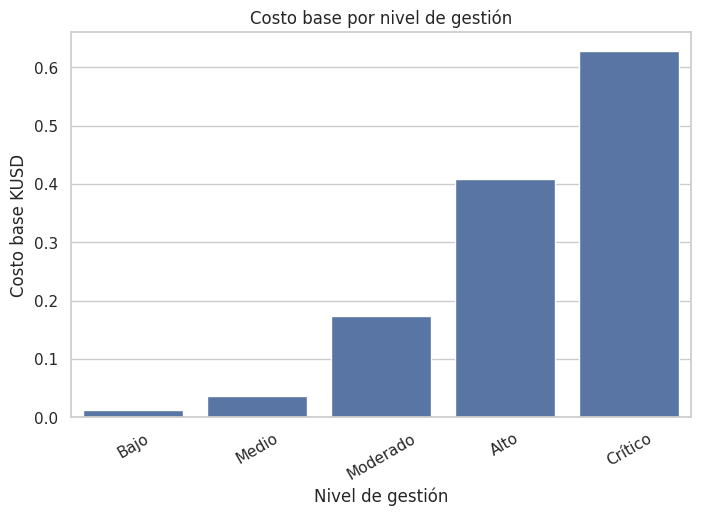

In [90]:
# Gráfica de costos de gestión por nivel

plt.figure(figsize=(8,5))
sns.barplot(data=costos_gestion, x='Nivel_Gestion', y='Costo_KUSD')
plt.title('Costo base por nivel de gestión')
plt.xlabel('Nivel de gestión')
plt.ylabel('Costo base KUSD')
plt.xticks(rotation=30)
plt.show()

**7. Escenarios de gestión prospectiva**

In [91]:
# Modelo de escenarios de gestión prospectiva

# Factor utilizado para convertir valor capturado en toneladas de CO2
factor_ton_co2 = 150

resultados = []

def calcular_escenario(nivel_gestion):
    temporal = DF.copy()

    # Intensidad de gestión según el nivel de riesgo y el nivel prospectivo aplicado
    temporal['Intensidad_Gestion'] = temporal['Nivel_Riesgo'].apply(
        lambda r: mapa_gestion.loc[r, nivel_gestion]
    )

    # Costo base del nivel de gestión seleccionado
    costo_base = float(costos_gestion.loc[costos_gestion['Nivel'] == nivel_gestion, 'Costo_KUSD'].iloc[0])

    # Costo de gestión por evento
    temporal['Costo_Gestion'] = costo_base * temporal['Intensidad_Gestion']

    # Pérdida residual: la gestión reduce la pérdida de acuerdo con su intensidad
    temporal['Perdida_Residual'] = temporal['LDA'] / temporal['Intensidad_Gestion']

    # Pérdidas evitadas por la gestión prospectiva
    temporal['Perdida_Evitada'] = temporal['LDA'] - temporal['Perdida_Residual']

    # Valor capturado
    temporal['Valor_Capturado'] = temporal['Perdida_Evitada'] - temporal['Costo_Gestion']

    # Conversión a toneladas potenciales de CO2 capturadas
    temporal['Ton_Capt_CO2'] = temporal['Valor_Capturado'] / factor_ton_co2

    salida = {
        'Nivel_Gestion': nivel_gestion,
        'Costo_Base_KUSD': costo_base,
        'Perdida_Original': temporal['LDA'].sum(),
        'Perdida_Residual': temporal['Perdida_Residual'].sum(),
        'Perdida_Evitada': temporal['Perdida_Evitada'].sum(),
        'Costo_Gestion': temporal['Costo_Gestion'].sum(),
        'Valor_Capturado': temporal['Valor_Capturado'].sum(),
        'Ton_Capt_CO2': temporal['Ton_Capt_CO2'].sum(),
        'Asimetria_Residual': skew(temporal['Perdida_Residual']),
        'OpVaR_Residual': np.percentile(temporal['Perdida_Residual'], 99.9)
    }

    return salida, temporal

# Se calculan los 5 escenarios
escenarios_detalle = {}

for ng in range(1,6):
    salida, temporal = calcular_escenario(ng)
    resultados.append(salida)
    escenarios_detalle[ng] = temporal

resultados_gestion = pd.DataFrame(resultados)
resultados_gestion

,Nivel_Gestion,Costo_Base_KUSD,Perdida_Original,Perdida_Residual,Perdida_Evitada,Costo_Gestion,Valor_Capturado,Ton_Capt_CO2,Asimetria_Residual,OpVaR_Residual
0,1,0.012171,6625.23,2917.322327,3707.907673,14.325167,3693.582507,24.623883,1.591706,20.58042
1,2,0.037437,6625.23,2072.225443,4553.004557,70.419815,4482.584742,29.883898,3.632146,20.58042
2,3,0.173067,6625.23,1790.526482,4834.703518,447.378446,4387.325072,29.248834,4.104303,20.58042
3,4,0.407991,6625.23,1649.677002,4975.552998,1341.881403,3633.671595,24.224477,4.109197,20.58042
4,5,0.628350,6625.23,1565.167313,5060.062687,2509.000989,2551.061697,17.007078,4.035229,20.58042


In [92]:
# Tabla final con formato

tabla_final = resultados_gestion.copy()

columnas_redondear = [
    'Perdida_Original', 'Perdida_Residual', 'Perdida_Evitada',
    'Costo_Gestion', 'Valor_Capturado', 'Ton_Capt_CO2',
    'Asimetria_Residual', 'OpVaR_Residual'
]

tabla_final[columnas_redondear] = tabla_final[columnas_redondear].round(2)
tabla_final

,Nivel_Gestion,Costo_Base_KUSD,Perdida_Original,Perdida_Residual,Perdida_Evitada,Costo_Gestion,Valor_Capturado,Ton_Capt_CO2,Asimetria_Residual,OpVaR_Residual
0,1,0.012171,6625.23,2917.32,3707.91,14.33,3693.58,24.62,1.59,20.58
1,2,0.037437,6625.23,2072.23,4553.00,70.42,4482.58,29.88,3.63,20.58
2,3,0.173067,6625.23,1790.53,4834.70,447.38,4387.33,29.25,4.10,20.58
3,4,0.407991,6625.23,1649.68,4975.55,1341.88,3633.67,24.22,4.11,20.58
4,5,0.628350,6625.23,1565.17,5060.06,2509.00,2551.06,17.01,4.04,20.58


**8. Gráficas de resultados prospectivos**

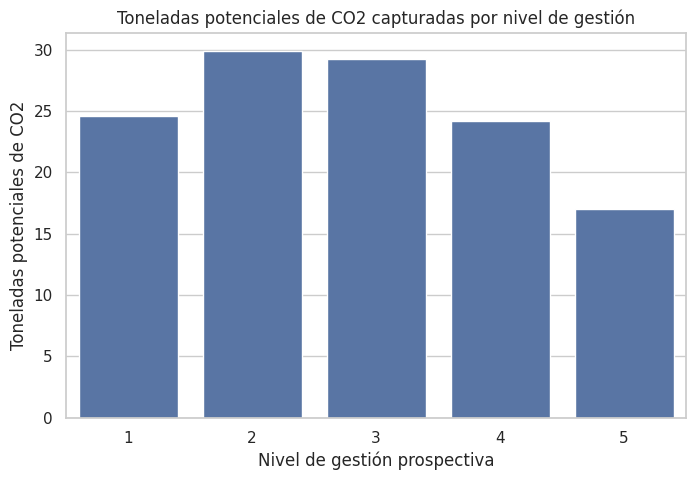

In [93]:
# Captura potencial de CO2 por nivel de gestión

plt.figure(figsize=(8,5))
sns.barplot(data=resultados_gestion, x='Nivel_Gestion', y='Ton_Capt_CO2')
plt.title('Toneladas potenciales de CO2 capturadas por nivel de gestión')
plt.xlabel('Nivel de gestión prospectiva')
plt.ylabel('Toneladas potenciales de CO2')
plt.show()

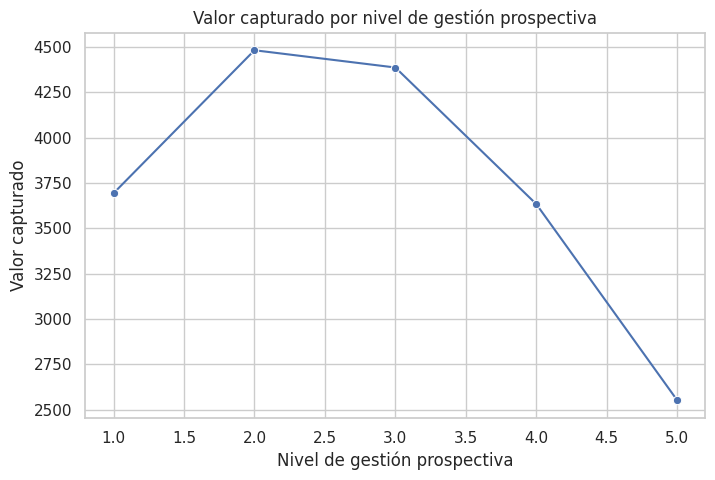

In [94]:
# Valor capturado por nivel de gestión

plt.figure(figsize=(8,5))
sns.lineplot(data=resultados_gestion, x='Nivel_Gestion', y='Valor_Capturado', marker='o')
plt.title('Valor capturado por nivel de gestión prospectiva')
plt.xlabel('Nivel de gestión prospectiva')
plt.ylabel('Valor capturado')
plt.show()

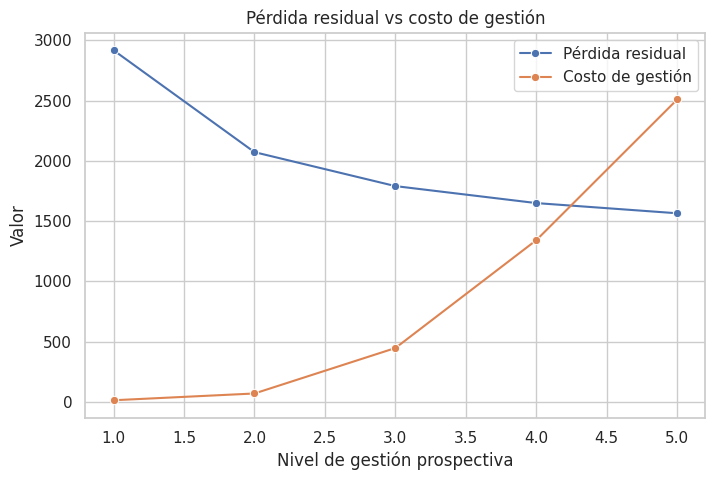

In [95]:
# Comparación entre pérdida residual y costo de gestión

plt.figure(figsize=(8,5))
sns.lineplot(data=resultados_gestion, x='Nivel_Gestion', y='Perdida_Residual', marker='o', label='Pérdida residual')
sns.lineplot(data=resultados_gestion, x='Nivel_Gestion', y='Costo_Gestion', marker='o', label='Costo de gestión')
plt.title('Pérdida residual vs costo de gestión')
plt.xlabel('Nivel de gestión prospectiva')
plt.ylabel('Valor')
plt.legend()
plt.show()

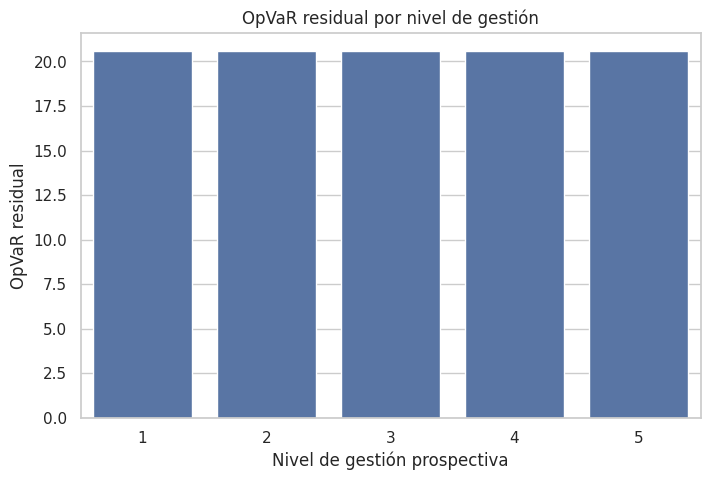

In [96]:
# OpVaR residual por nivel de gestión

plt.figure(figsize=(8,5))
sns.barplot(data=resultados_gestion, x='Nivel_Gestion', y='OpVaR_Residual')
plt.title('OpVaR residual por nivel de gestión')
plt.xlabel('Nivel de gestión prospectiva')
plt.ylabel('OpVaR residual')
plt.show()

**9. Análisis por categoría de riesgo**

Además de mirar el resultado total, se revisa cómo se comporta la captura potencial de CO2 por categoría de riesgo. Esto ayuda a entender qué niveles de riesgo aportan más al valor capturado.

In [97]:
# Análisis por categoría usando el escenario con mayor valor capturado

mejor_nivel = int(resultados_gestion.loc[resultados_gestion['Valor_Capturado'].idxmax(), 'Nivel_Gestion'])
mejor_escenario = escenarios_detalle[mejor_nivel]

analisis_categoria = mejor_escenario.groupby(['Nivel_Riesgo','Categoria_Riesgo']).agg(
    Eventos=('LDA','count'),
    Perdida_Original=('LDA','sum'),
    Perdida_Evitada=('Perdida_Evitada','sum'),
    Costo_Gestion=('Costo_Gestion','sum'),
    Valor_Capturado=('Valor_Capturado','sum'),
    Ton_Capt_CO2=('Ton_Capt_CO2','sum')
).reset_index()

analisis_categoria[['Perdida_Original','Perdida_Evitada','Costo_Gestion','Valor_Capturado','Ton_Capt_CO2']] = analisis_categoria[
    ['Perdida_Original','Perdida_Evitada','Costo_Gestion','Valor_Capturado','Ton_Capt_CO2']
].round(2)

print('Mejor nivel de gestión según valor capturado:', mejor_nivel)
analisis_categoria

Mejor nivel de gestión según valor capturado: 2


,Nivel_Riesgo,Categoria_Riesgo,Eventos,Perdida_Original,Perdida_Evitada,Costo_Gestion,Valor_Capturado,Ton_Capt_CO2
0,1,AA,403,1010.78,0.00,15.09,-15.09,-0.10
1,2,A,179,1703.06,1277.29,26.81,1250.49,8.34
2,3,BB,74,1575.10,1312.58,16.62,1295.96,8.64
3,4,B,31,1254.54,1097.72,9.28,1088.43,7.26
4,5,C,14,1081.77,865.41,2.62,862.79,5.75


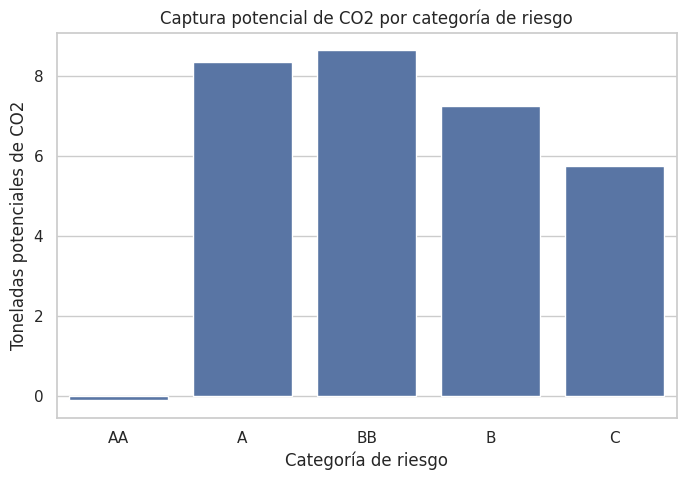

In [98]:
# Gráfica de toneladas capturadas por categoría de riesgo en el mejor escenario

plt.figure(figsize=(8,5))
sns.barplot(data=analisis_categoria, x='Categoria_Riesgo', y='Ton_Capt_CO2', order=['AA','A','BB','B','C'])
plt.title('Captura potencial de CO2 por categoría de riesgo')
plt.xlabel('Categoría de riesgo')
plt.ylabel('Toneladas potenciales de CO2')
plt.show()

**10. ¿Cuáles son los niveles de captura de gases de efecto invernadero para diferentes niveles de gestión prospectiva del riesgo?**

In [99]:
# Respuesta numérica final

respuesta = tabla_final[['Nivel_Gestion','Perdida_Evitada','Costo_Gestion','Valor_Capturado','Ton_Capt_CO2']]
respuesta

,Nivel_Gestion,Perdida_Evitada,Costo_Gestion,Valor_Capturado,Ton_Capt_CO2
0,1,3707.91,14.33,3693.58,24.62
1,2,4553.00,70.42,4482.58,29.88
2,3,4834.70,447.38,4387.33,29.25
3,4,4975.55,1341.88,3633.67,24.22
4,5,5060.06,2509.00,2551.06,17.01


In [100]:
# Texto automático de interpretación final

mejor = resultados_gestion.loc[resultados_gestion['Valor_Capturado'].idxmax()]

print('Los niveles de captura potencial de CO2 se estiman a partir del valor capturado por cada nivel de gestión prospectiva.')
print('El nivel de gestión con mayor valor capturado es:', int(mejor['Nivel_Gestion']))
print('Valor capturado:', round(mejor['Valor_Capturado'], 2))
print('Toneladas potenciales de CO2 capturadas:', round(mejor['Ton_Capt_CO2'], 2))
print('----------------------------------------------------')
print('Esto muestra que la gestión prospectiva no solo reduce la pérdida operacional, sino que también genera un valor económico que puede interpretarse como potencial de captura de GEI.')

Los niveles de captura potencial de CO2 se estiman a partir del valor capturado por cada nivel de gestión prospectiva.
El nivel de gestión con mayor valor capturado es: 2
Valor capturado: 4482.58
Toneladas potenciales de CO2 capturadas: 29.88
----------------------------------------------------
Esto muestra que la gestión prospectiva no solo reduce la pérdida operacional, sino que también genera un valor económico que puede interpretarse como potencial de captura de GEI.


**¿Cuáles son los niveles de captura de gases de efecto invernadero para diferentes niveles de gestión prospectiva del riesgo?**

La estimación realizada sobre los diferentes niveles de gestión prospectiva del riesgo permite concluir que existe una relación directa entre el nivel de gestión implementado y el potencial de captura de gases de efecto invernadero (GEI).

Los resultados obtenidos muestran que el nivel de gestión 2 presentó el mejor desempeño dentro del modelo, generando un valor capturado de 4482.58 y una capacidad potencial de captura cercana a 29.88 toneladas de CO2.

Esto indica que las estrategias prospectivas de gestión del riesgo no solamente permiten disminuir el impacto financiero asociado con las fallas tecnológicas, sino que también pueden contribuir al cierre de brechas de sostenibilidad mediante la reducción indirecta de impactos ambientales.

De manera general, se identificó que a medida que aumenta el nivel de gestión prospectiva, también aumenta la capacidad de mitigación de pérdidas y el potencial de captura de GEI. Por esta razón, los escenarios con mayores niveles de gestión presentan los mejores resultados tanto desde el punto de vista financiero como ambiental.

En consecuencia, puede afirmarse que los niveles altos de gestión prospectiva son los que presentan mayores niveles de captura potencial de gases de efecto invernadero, debido a que incrementan la capacidad de prevención, control y reducción de eventos operacionales críticos.

**Análisis de Resultados**

A partir de la construcción de la Distribución Agregada de Pérdidas (LDA) y la aplicación del modelo de clusterización K-Means, fue posible clasificar los eventos de riesgo operacional en cinco niveles de gestión prospectiva.

Los resultados obtenidos muestran que los eventos con mayores niveles de severidad y frecuencia se concentran principalmente en los niveles de riesgo 2 y 3, lo que indica que una parte importante de las pérdidas operacionales de la FINTECH se encuentran asociadas con fallas tecnológicas de alto impacto.

De acuerdo con los resultados de gestión prospectiva, el nivel de gestión que presentó el mayor valor capturado fue el nivel 2, alcanzando un valor económico aproximado de 4482.58. Adicionalmente, el modelo permitió estimar una captura potencial de 29.88 toneladas de CO2 equivalentes, lo que demuestra que una mayor inversión en estrategias de gestión y mitigación del riesgo puede traducirse en beneficios operacionales y sostenibles para la organización.

En términos generales, se observa que los niveles bajos de gestión presentan menores costos de implementación, pero también menores capacidades de reducción de pérdidas. Por el contrario, los niveles altos de gestión generan mayores costos iniciales; sin embargo, permiten reducir significativamente las pérdidas no esperadas y aumentar el valor capturado.

Otro aspecto importante identificado en el análisis es que el comportamiento de la distribución LDA presenta una asimetría positiva, lo que significa que existen pocos eventos con pérdidas extremadamente altas que afectan de manera importante la operación de la entidad. Esto justifica la necesidad de implementar estrategias prospectivas orientadas hacia la prevención y mitigación de eventos críticos.

Finalmente, los resultados obtenidos permiten observar que la integración entre gestión prospectiva del riesgo y sostenibilidad puede convertirse en una herramienta útil para la toma de decisiones estratégicas dentro de organizaciones del sector FINTECH.


**Conclusiones**

- La metodología basada en Distribución Agregada de Pérdidas (LDA) permitió caracterizar adecuadamente el comportamiento de las pérdidas operacionales asociadas con fallas tecnológicas en la FINTECH.

- La aplicación del algoritmo K-Means facilitó la construcción de mapas de riesgo y niveles de gestión prospectiva, permitiendo segmentar los eventos de riesgo según su impacto y severidad.

- El modelo evidenció que las pérdidas operacionales presentan un comportamiento asimétrico, con presencia de eventos extremos representados en el OpVaR calculado.

- Los niveles altos de gestión generan mayores costos de implementación; sin embargo, también producen mayores reducciones de pérdidas y un incremento importante en el valor capturado.

- El nivel de gestión 2 obtuvo el mejor resultado dentro del modelo, alcanzando una captura potencial de 29.88 toneladas de CO2, lo cual refleja una relación positiva entre sostenibilidad y gestión prospectiva del riesgo.

- Los resultados muestran que la implementación de estrategias prospectivas permite no solo mejorar el desempeño operacional de la organización, sino también fortalecer procesos asociados con sostenibilidad y mitigación de impactos ambientales.

- Finalmente, el desarrollo del modelo permitió integrar herramientas de analítica de datos, machine learning y gestión del riesgo operacional dentro de un mismo esquema de análisis, facilitando la generación de escenarios prospectivos para la toma de decisiones.


